In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Training_Input/ISIC_0012706.jpg
/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Training_Input/ISIC_0010192.jpg
/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Training_Input/ISIC_0010017.jpg
/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Training_Input/ISIC_0013000.jpg
/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Training_Input/ISIC_0013166.jpg
/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Training_Input/ISIC_0003308.jpg
/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Training_Input/ISIC_0012332.jpg
/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Training_Input/ISIC_0014291.jpg
/kaggle/

In [2]:
import os

base_path = '/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation'

images_path = os.path.join(base_path, 'ISIC2018_Task1-2_Training_Input')
masks_path = os.path.join(base_path, 'ISIC2018_Task1_Training_GroundTruth')

print(f'Zdjęcia: {len(os.listdir(images_path))}')
print(f'Maski: {len(os.listdir(masks_path))}')

Zdjęcia: 2596
Maski: 2596


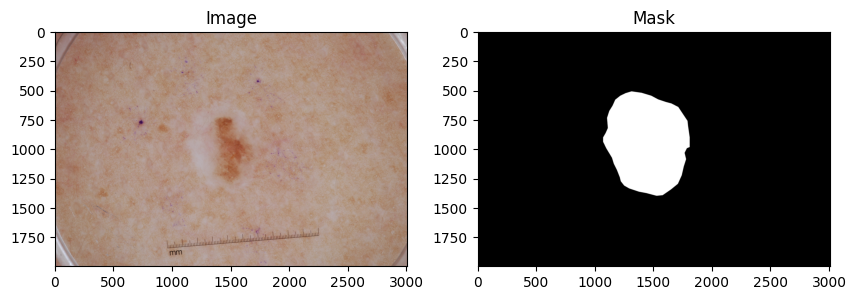

In [3]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# pierwsze zdjęcie i jego maska
img_name = os.listdir(images_path)[0]
mask_name = img_name.replace('.jpg', '_segmentation.png')

img = Image.open(os.path.join(images_path, img_name))
mask = Image.open(os.path.join(masks_path, mask_name))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img)
axes[0].set_title('Image')
axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Mask')
plt.show()

In [4]:
!pip install segmentation-models-pytorch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.2 MB/s eta 0:00:00


In [5]:
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np

# sprawdź GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# zainstaluj bibliotekę
import subprocess
subprocess.run(['pip', 'install', 'segmentation-models-pytorch', '-q'])

Device: cuda


CompletedProcess(args=['pip', 'install', 'segmentation-models-pytorch', '-q'], returncode=0)

In [6]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os

class ISICDataset(Dataset):
    def __init__(self, images_path, masks_path, filenames, img_size=256):
        self.images_path = images_path
        self.masks_path = masks_path
        self.filenames = filenames
        self.img_size = img_size

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img_name = self.filenames[idx]
        mask_name = img_name.replace('.jpg', '_segmentation.png')

        img = Image.open(os.path.join(self.images_path, img_name)).convert('RGB')
        mask = Image.open(os.path.join(self.masks_path, mask_name)).convert('L')

        img = img.resize((self.img_size, self.img_size))
        mask = mask.resize((self.img_size, self.img_size))

        img = torch.tensor(np.array(img)).permute(2, 0, 1).float() / 255.0
        mask = torch.tensor(np.array(mask)).float() / 255.0
        mask = (mask > 0.5).float().unsqueeze(0)

        return img, mask

# podziel na train/val
all_files = [f for f in os.listdir(images_path) if f.endswith('.jpg')]
train_files = all_files[:2000]
val_files = all_files[2000:]

train_dataset = ISICDataset(images_path, masks_path, train_files)
val_dataset = ISICDataset(images_path, masks_path, val_files)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print(f'Train: {len(train_dataset)} zdjęć')
print(f'Val: {len(val_dataset)} zdjęć')

Train: 2000 zdjęć
Val: 594 zdjęć


In [7]:
# Model
model = smp.Unet(
    encoder_name='efficientnet-b0',
    encoder_weights='imagenet',
    in_channels=3,
    classes=1,
).to(device)

# Loss i optimizer
criterion = smp.losses.DiceLoss(mode='binary')
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Trening
epochs = 5

for epoch in range(epochs):
    # Train
    model.train()
    train_loss = 0
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Val
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()

    print(f'Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f}')

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Epoch [1/5] | Train Loss: 0.2058 | Val Loss: 0.1386
Epoch [2/5] | Train Loss: 0.1346 | Val Loss: 0.1583
Epoch [3/5] | Train Loss: 0.1195 | Val Loss: 0.1126
Epoch [4/5] | Train Loss: 0.1091 | Val Loss: 0.1340
Epoch [5/5] | Train Loss: 0.0972 | Val Loss: 0.1194


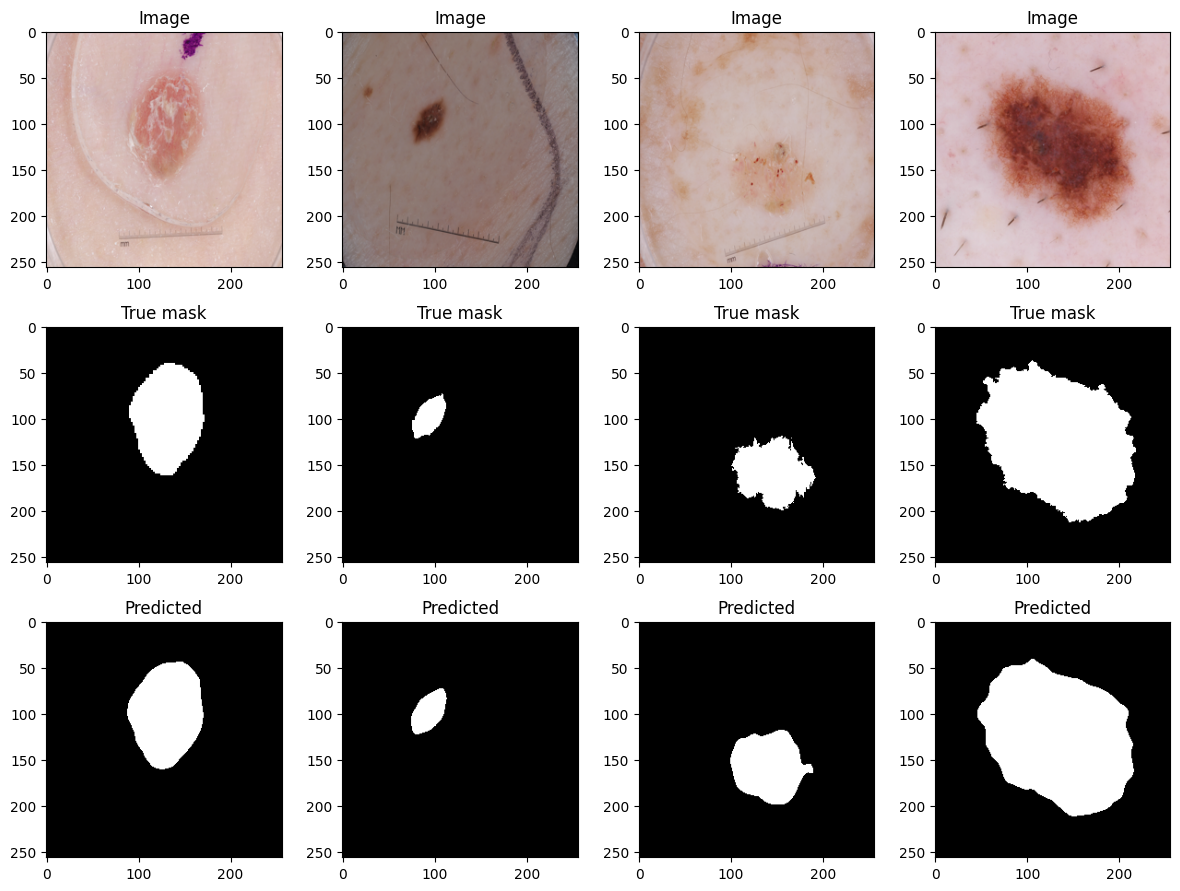

In [8]:
import matplotlib.pyplot as plt

model.eval()
images, masks = next(iter(val_loader))
images, masks = images.to(device), masks.to(device)

with torch.no_grad():
    outputs = torch.sigmoid(model(images))
    predicted = (outputs > 0.5).float()

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for i in range(4):
    axes[0][i].imshow(images[i].cpu().permute(1,2,0))
    axes[0][i].set_title('Image')
    axes[1][i].imshow(masks[i].cpu().squeeze(), cmap='gray')
    axes[1][i].set_title('True mask')
    axes[2][i].imshow(predicted[i].cpu().squeeze(), cmap='gray')
    axes[2][i].set_title('Predicted')
plt.tight_layout()
plt.show()

In [9]:
torch.save(model.state_dict(), '/kaggle/working/unet_melanoma.pth')
print('Model zapisany!')

Model zapisany!
